In [2]:
import csv

def fix_csv(input_file, output_file):
    with open(input_file, 'r', encoding='utf-8') as infile, \
         open(output_file, 'w', encoding='utf-8', newline='') as outfile:
        reader = csv.reader(infile)
        writer = csv.writer(outfile)
        for row in reader:
            # Attempt to fix potential quote issues:
            fixed_row = [field.replace('"', '""') for field in row]  # Escape inner quotes
            writer.writerow(fixed_row)

# Usage:
fix_csv('/home/weichao/Sentiment Analysis/data/Combined Data.csv', '/home/weichao/Sentiment Analysis/data/fixed_data.csv')  # Creates a new fixed CSV file
CSV_FILE_PATH = '/home/weichao/Sentiment Analysis/data/fixed_data.csv'  # Use the fixed CSV for loading

In [ ]:
#loading data


import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from sklearn.utils import shuffle 

# --- Configuration ---
TEXT_COLUMN = 'statement' # Name of the column containing the text
LABEL_COLUMN = 'status' # Name of the column containing the numerical labels

# Choose a pre-trained model tokenizer.
PRETRAINED_MODEL_NAME = 'distilbert-base-uncased'

MAX_LENGTH = 128  # Maximum sequence length for tokenization
BATCH_SIZE = 16   # Batch size for training

TRAIN_VAL_SIZE = 50000 # Number of samples for combined training and validation
RANDOM_STATE = 42      # Seed for reproducibility during shuffling

# --- 1. Load Data using Pandas ---
try:
    df = pd.read_csv(CSV_FILE_PATH, on_bad_lines='skip')
    print(f"Successfully loaded {len(df)} rows from {CSV_FILE_PATH}")
    # Basic validation
    if TEXT_COLUMN not in df.columns:
        raise ValueError(f"Text column '{TEXT_COLUMN}' not found in the CSV.")
    if LABEL_COLUMN not in df.columns:
        raise ValueError(f"Label column '{LABEL_COLUMN}' not found in the CSV.")
    if len(df) <= TRAIN_VAL_SIZE:
        raise ValueError(f"Dataset size less than ({TRAIN_VAL_SIZE}). Please provide a larger dataset.")

except FileNotFoundError:
    print(f"Error: CSV file not found at {CSV_FILE_PATH}")
except ValueError as ve:
    print(f"Error: {ve}")
except Exception as e:
    print(f"An unexpected error occurred while loading the CSV: {e}")
    
# --- 2. Shuffle the Entire Dataset ---
df_shuffled = shuffle(df, random_state=RANDOM_STATE)

label_encoder = LabelEncoder()
df_shuffled_labels = label_encoder.fit_transform(df_shuffled[LABEL_COLUMN])
df_shuffled_texts = [str(text) for text in df_shuffled[TEXT_COLUMN].tolist()]

# Take the first TRAIN_VAL_SIZE rows for training and validation
train_shuffled_text_df = df_shuffled_texts[:TRAIN_VAL_SIZE].copy()
train_shuffled_labels_df = df_shuffled_labels[:TRAIN_VAL_SIZE].copy()

# Take the remaining rows for testing
test_shuffled_text_df = df_shuffled_texts[TRAIN_VAL_SIZE:].copy()
test_shuffled_labels_df = df_shuffled_labels[TRAIN_VAL_SIZE:].copy()

print("\n--- Data Loading and Splitting Complete ---")
# Translate label to int


print(f"Sample Text: {test_shuffled_text_df[0]}")
print(f"Sample Label: {test_shuffled_labels_df[0]}")
print(f"Number of unique labels: {len(set(train_shuffled_labels_df))}")


# --- 2. Load Tokenizer ---
print(f"\nLoading tokenizer for model: {PRETRAINED_MODEL_NAME}...")
try:
    # AutoTokenizer automatically selects the correct tokenizer class based on the pre-trained model name.
    tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)
    print("Tokenizer loaded successfully.")
except Exception as e:
    print(f"Error loading tokenizer: {e}")
    print("Please ensure the model name is correct and you have an internet connection.")

# --- 3. Tokenize Data ---
print(f"\nTokenizing text data (max length: {MAX_LENGTH})...")

# Use the tokenizer directly on the list of texts.
# padding='max_length': Pad shorter sequences to MAX_LENGTH.
# truncation=True: Truncate longer sequences to MAX_LENGTH.
# return_tensors='tf': Return TensorFlow tensors.
try:
    # Tokenize in batches for potentially large datasets 
    encodings = tokenizer(
        train_shuffled_text_df,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='tf' # Return TensorFlow tensors directly
    )
    print("Tokenization complete.")
    print("Keys in encoding:", encodings.keys())
    print("Shape of input_ids:", encodings['input_ids'].shape)

except Exception as e:
    print(f"An error occurred during tokenization: {e}")
    exit()


# --- 4. Create TensorFlow Dataset ---
print("\nCreating TensorFlow dataset...")

# Create a dataset from the tokenized encodings and the labels.
try:
    # Create dataset from the dictionary of encodings and labels
    tf_dataset = tf.data.Dataset.from_tensor_slices(
        (
            # The input data for the model is typically a dictionary containing 'input_ids', 'attention_mask', etc.
            dict(encodings),
            # The corresponding labels
            train_shuffled_labels_df
        )
    )
    print("TensorFlow dataset created successfully.")


    buffer_size = len(df)
    tf_dataset = tf_dataset.shuffle(buffer_size=buffer_size).batch(BATCH_SIZE)
    print(f"Dataset shuffled and batched (batch size: {BATCH_SIZE}).")

    # Optional: Prefetch for performance
    tf_dataset = tf_dataset.prefetch(tf.data.AUTOTUNE)
    print("Dataset prefetching enabled.")

    # inspect an element
    for batch in tf_dataset.take(1):
        input_batch, label_batch = batch
        print("\nSample batch structure:")
        print("Input keys:", input_batch.keys())
        print("Shape of input_ids in batch:", input_batch['input_ids'].shape)
        print("Shape of labels in batch:", label_batch.shape)
        print("Sample labels in batch:", label_batch.numpy())

except Exception as e:
    print(f"An error occurred while creating the TensorFlow dataset: {e}")
    exit()

print("\n--- Data Loading and Preparation Complete ---")
print("The variable 'tf_dataset' now holds your prepared data.")

/home/weichao/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded 53043 rows from /home/weichao/Sentiment Analysis/data/fixed_data.csv

--- Data Loading and Splitting Complete ---
Sample Text: well, that's okay, as long as it helps him relax and think more clearly.
Sample Label: 3
Number of unique labels: 7

Loading tokenizer for model: distilbert-base-uncased...
Tokenizer loaded successfully.

Tokenizing text data (max length: 128)...


I0000 00:00:1746186520.572637   38701 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6246 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Tokenization complete.
Keys in encoding: dict_keys(['input_ids', 'attention_mask'])
Shape of input_ids: (50000, 128)

Creating TensorFlow dataset...
TensorFlow dataset created successfully.
Dataset shuffled and batched (batch size: 16).
Dataset prefetching enabled.

Sample batch structure:
Input keys: dict_keys(['input_ids', 'attention_mask'])
Shape of input_ids in batch: (16, 128)
Shape of labels in batch: (16,)
Sample labels in batch: [6 3 2 3 6 3 2 3 2 3 2 2 2 3 3 2]

--- Data Loading and Preparation Complete ---
The variable 'tf_dataset' now holds your prepared data.


2025-05-02 21:48:40.899956: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
#model training

import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification
import numpy as np 

# Check if GPU is available and set it as the default device
if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Using GPU for computations.")
    tf.debugging.set_log_device_placement(True)  # Optional: Logs device placement for debugging
else:
    print("GPU is not available. Using CPU for computations.")

PRETRAINED_MODEL_NAME = 'distilbert-base-uncased' # Placeholder

try:
    # Assuming 'labels' list exists from the previous data loading step
    if 'labels' in globals() and train_shuffled_labels_df is not None:
         NUM_LABELS = len(np.unique(train_shuffled_labels_df))
         print(f"Inferred number of labels from data: {NUM_LABELS}")
    else:
         # *** SET MANUALLY IF 'labels' is not available ***
         NUM_LABELS = 7
         print(f"Number of labels set manually: {NUM_LABELS}")
except NameError:
     # *** SET MANUALLY IF 'labels' is not defined ***
     NUM_LABELS = 7 # Example: Replace with your actual number of classes
     print(f"Number of labels set manually (due to NameError): {NUM_LABELS}")
except Exception as e:
    print(f"Could not automatically determine number of labels: {e}")
    # *** SET MANUALLY AS FALLBACK ***
    NUM_LABELS = 7 # Example: Replace with your actual number of classes
    print(f"Number of labels set manually (due to exception): {NUM_LABELS}")


# --- Load Pre-trained Model ---
print(f"\nLoading pre-trained model: {PRETRAINED_MODEL_NAME} for sequence classification...")

try:
    # TFAutoModelForSequenceClassification automatically loads the TensorFlow
    # version of the model with a classification head.
    # - PRETRAINED_MODEL_NAME: Specifies the model architecture and weights.
    # - num_labels: Configures the output layer of the classification head.
    model = TFAutoModelForSequenceClassification.from_pretrained(
        PRETRAINED_MODEL_NAME,
        num_labels=NUM_LABELS
    )

    print("\nModel loaded successfully!")

    # Optional: Print model architecture summary
    print("\nModel Summary:")
    model.summary()

    # Store the model configuration if needed later
    model_config = model.config
    print(f"\nModel Config Loaded (Example: id2label mapping): {model_config.id2label}")


except OSError as e:
    print(f"\nError loading model: {e}")
    print(f"Could not find model '{PRETRAINED_MODEL_NAME}' on Hugging Face Hub or locally.")
    print("Please ensure the model name is correct, you have an internet connection,")
    print("and the model is compatible with TFAutoModelForSequenceClassification.")
    exit()
except Exception as e:
    print(f"\nAn unexpected error occurred while loading the model: {e}")
    # Optionally exit
    # exit()

print("\n--- Model Loading Complete ---")
# The variable 'model' now holds your TensorFlow/Keras model, ready for compilation and fine-tuning.
import tensorflow as tf
import numpy as np
import math


NUM_LABELS = 7  # As specified by the user
LEARNING_RATE = 5e-5  # Common learning rate for fine-tuning transformers (can be tuned: 2e-5, 3e-5, 5e-5)

EPOCHS = 3

print("Preparing training and validation datasets...")

try:
    # Full run: Split the dataset (e.g., 90% train, 10% val)
    dataset_size = tf.data.experimental.cardinality(tf_dataset).numpy()
    if dataset_size == tf.data.experimental.UNKNOWN_CARDINALITY or dataset_size <= 0:
        print("Warning: Could not determine dataset size automatically. Using estimated sizes or default split.")
        # Fallback strategy if size is unknown - this might be inaccurate
        # Consider calculating size beforehand if possible
        estimated_total_batches = 1000 # Provide a reasonable estimate or calculate if possible
        val_size = int(0.15 * estimated_total_batches)
        train_size = estimated_total_batches - val_size
        print(f"Using estimated split: ~{train_size} train batches, {val_size} val batches.")
        # Apply the split using take/skip based on estimates
        val_dataset = tf_dataset.take(val_size)
        train_dataset = tf_dataset.skip(val_size)
    else:
        print(f"Total batches: {dataset_size}")
        val_size = max(1, int(0.15 * dataset_size))  # Ensure at least 1 batch for validation
        train_size = dataset_size - val_size
        print(f"Using {train_size} batches for training and {val_size} batches for validation (Full Run).")
        # Apply the split
        val_dataset = tf_dataset.take(val_size)
        train_dataset = tf_dataset.skip(val_size)

    # Verify dataset sizes (optional)
    print(f"Train dataset cardinality: {tf.data.experimental.cardinality(train_dataset)}")
    print(f"Validation dataset cardinality: {tf.data.experimental.cardinality(val_dataset)}")
    print("Dataset preparation complete.")


except NameError as ne:
    print(f"Error: Required variable not found: {ne}")
    print("Ensure 'tf_dataset' exists from the data loading step.")
    exit()
except Exception as e:
    print(f"An error occurred during dataset splitting: {e}")
    exit()


# --- 2. Compile the Model ---
print("\nCompiling the model...")

# Use AdamW optimizer, which is recommended for Transformers
optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE)

# Use SparseCategoricalCrossentropy loss because labels are integers (0-6)
# Set from_logits=True because the Hugging Face model outputs raw scores (logits)
# before the final activation function (like softmax).
loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Use SparseCategoricalAccuracy metric for monitoring
metric = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')

try:
    # Ensure the loaded model has the correct number of labels in its config
    if model.config.num_labels != NUM_LABELS:
        print(f"Warning: Model config has {model.config.num_labels} labels, but NUM_LABELS is set to {NUM_LABELS}.")
        print("Re-check model loading step or NUM_LABELS setting.")
        # Potentially exit or try to proceed cautiously
        # exit()

    model.compile(optimizer=optimizer, loss=loss_function, metrics=[metric])
    print("Model compiled successfully.")

except NameError as ne:
    print(f"Error: Required variable not found: {ne}")
    print("Ensure 'model' exists from the model loading step.")
    exit()
except Exception as e:
    print(f"An error occurred during model compilation: {e}")
    exit()


# --- 3. Fine-tune the Model ---
print(f"\nStarting fine-tuning for {EPOCHS} epochs...")

# Optional: Add callbacks for better training control
# tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
# early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1) # Stop if val_loss doesn't improve for 1 epoch

try:
    # Check if datasets are empty before fitting
    if tf.data.experimental.cardinality(train_dataset) == 0:
         print("Error: Training dataset is empty. Check dataset splitting logic and source data.")
         exit()
    if tf.data.experimental.cardinality(val_dataset) == 0:
         print("Error: Validation dataset is empty. Check dataset splitting logic and source data.")
         exit()

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS
        # Optional: Add callbacks here
        # callbacks=[tensorboard_callback, early_stopping_callback]
    )

    print("\nFine-tuning complete!")
    print("Training History:", history.history)

except Exception as e:
    print(f"\nAn error occurred during model training: {e}")
    # Common issues: OOM (Out of Memory) errors - try reducing BATCH_SIZE.
    # Input data format errors - double-check the tf_dataset structure.

print("\n--- Fine-tuning Process Finished ---")



GPU is available. Using GPU for computations.
Number of labels set manually: 7

Loading pre-trained model: distilbert-base-uncased for sequence classification...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 


Model loaded successfully!

Model Summary:
Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  5383      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66958855 (255.43 MB)
Trainable params: 66958855 (255.43 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

M

I0000 00:00:1746186548.968067   40186 service.cc:152] XLA service 0x76b41e90c150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746186548.968086   40186 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-05-02 21:49:08.979919: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746186549.003003   40186 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1746186549.098569   40186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2657/2657 [==============================] - 356s 127ms/step - loss: 0.5903 - accuracy: 0.7647 - val_loss: 0.4581 - val_accuracy: 0.8138
Epoch 2/3
2657/2657 [==============================] - 317s 119ms/step - loss: 0.4179 - accuracy: 0.8301 - val_loss: 0.3161 - val_accuracy: 0.8775
Epoch 3/3
2657/2657 [==============================] - 317s 119ms/step - loss: 0.3252 - accuracy: 0.8664 - val_loss: 0.2140 - val_accuracy: 0.9240

Fine-tuning complete!
Training History: {'loss': [0.590295672416687, 0.41787126660346985, 0.3251841068267822], 'accuracy': [0.7646546959877014, 0.8300950527191162, 0.8664141893386841], 'val_loss': [0.45812758803367615, 0.31609925627708435, 0.21399793028831482], 'val_accuracy': [0.8138354420661926, 0.8775373697280884, 0.924011766910553]}

--- Fine-tuning Process Finished ---


--- Starting Comparison: Fine-tuned vs. Original Model ---
Using existing 'model' variable as 'finetuned_model'.
Found 3043 samples in the test set.
Encoding test labels...
Class names from label encoder: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Tokenizing test text data (max length: 128)...
Creating TensorFlow dataset for evaluation...
Evaluation dataset created and batched.

Loading ORIGINAL pre-trained model: distilbert-base-uncased...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Original pre-trained model loaded successfully.

Running predictions for: Fine-tuned Model...


2025-05-02 22:20:56.069925: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Predictions complete.

--- Evaluation Metrics (Fine-tuned Model - Test Set) ---

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.86      0.83      0.84       229
             Bipolar       0.88      0.83      0.85       174
          Depression       0.78      0.76      0.77       877
              Normal       0.95      0.94      0.95       924
Personality disorder       0.71      0.81      0.76        69
              Stress       0.68      0.71      0.69       160
            Suicidal       0.71      0.76      0.73       610

            accuracy                           0.82      3043
           macro avg       0.80      0.80      0.80      3043
        weighted avg       0.82      0.82      0.82      3043


Confusion Matrix:
[[190  10   9   1   5  13   1]
 [  4 144  14   3   5   4   0]
 [  7   4 663  16   3   4 180]
 [  6   1  11 870   1  30   5]
 [  3   0   5   1  56   3   1]
 [ 11   3  11  13   9 113   0]
 [  0 

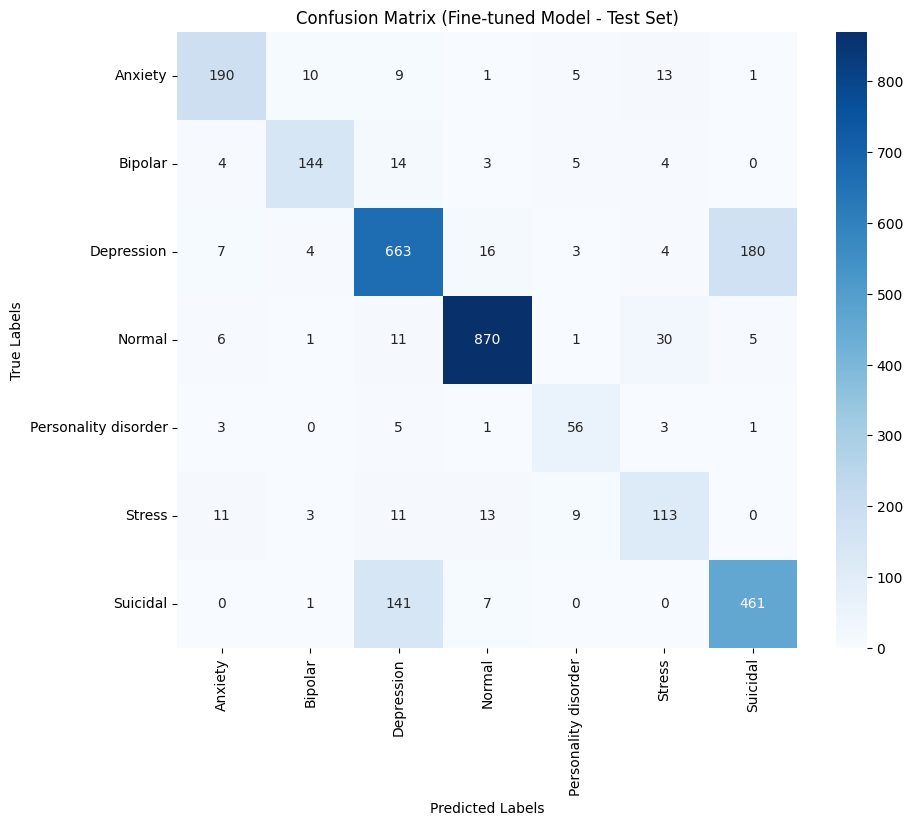


Running predictions for: Original Pre-trained Model...
Predictions complete.

--- Evaluation Metrics (Original Pre-trained Model - Test Set) ---

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.12      0.31      0.17       229
             Bipolar       0.08      0.51      0.14       174
          Depression       0.19      0.20      0.20       877
              Normal       0.27      0.04      0.06       924
Personality disorder       0.02      0.09      0.03        69
              Stress       0.00      0.00      0.00       160
            Suicidal       0.00      0.00      0.00       610

            accuracy                           0.12      3043
           macro avg       0.10      0.16      0.09      3043
        weighted avg       0.15      0.12      0.10      3043


Confusion Matrix:
[[ 71 104  39   3  12   0   0]
 [ 47  89  13  12  13   0   0]
 [171 373 175  27 129   0   2]
 [108 114 596  34  72   0   0]
 [

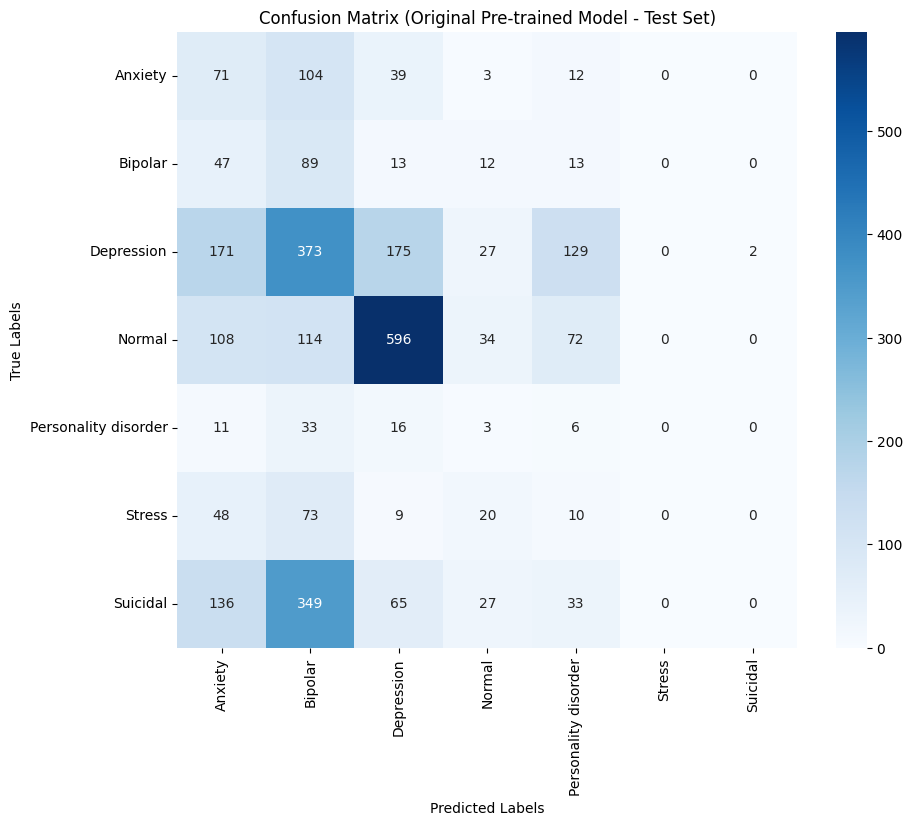


Consistency check: True labels match for both evaluations.

--- Model Comparison Complete ---


In [5]:
#model comparison

from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
# from sklearn.preprocessing import LabelEncoder # Not needed if label_encoder exists
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
MAX_LENGTH = 128  # Must be the SAME as used during training/tokenization
BATCH_SIZE = 16   # Evaluation batch size

ORIGINAL_PRETRAINED_MODEL_NAME = 'distilbert-base-uncased' # CHANGE AS NEEDED

print("--- Starting Comparison: Fine-tuned vs. Original Model ---")

# Rename the fine-tuned model variable for clarity if it's just 'model'
if 'model' in globals() and 'finetuned_model' not in globals():
     finetuned_model = model
     print("Using existing 'model' variable as 'finetuned_model'.")


# --- Function to Perform Evaluation ---
def evaluate_model(model_to_evaluate, model_name, test_dataset, class_names):
    """Runs predictions and generates evaluation metrics for a given model."""
    all_predictions = []
    all_true_labels = []
    print(f"\nRunning predictions for: {model_name}...")
    try:
        for batch in test_dataset:
            inputs, labels = batch
            outputs = model_to_evaluate(inputs, training=False) # Inference mode
            logits = outputs.logits
            predictions = tf.argmax(logits, axis=-1).numpy()
            all_predictions.extend(predictions)
            all_true_labels.extend(labels.numpy())

        print("Predictions complete.")
        all_predictions = np.array(all_predictions)
        all_true_labels = np.array(all_true_labels)

        if len(all_true_labels) == 0:
            raise ValueError(f"Evaluation resulted in zero true labels for {model_name}.")

        # Calculate and Display Metrics
        print(f"\n--- Evaluation Metrics ({model_name} - Test Set) ---")
        report = classification_report(
            all_true_labels,
            all_predictions,
            target_names=class_names,
            zero_division=0 # Handle cases where a class has no predictions/true labels in the test set
        )
        print("\nClassification Report:")
        print(report)

        cm = confusion_matrix(all_true_labels, all_predictions, labels=range(len(class_names))) # Ensure all labels are included
        print("\nConfusion Matrix:")
        print(cm)

        # Visualize Confusion Matrix
        print(f"\nVisualizing Confusion Matrix ({model_name})...")
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix ({model_name} - Test Set)')
        plt.show()

        return all_true_labels # Return true labels for consistency check if needed

    except Exception as e:
        print(f"An error occurred during evaluation for {model_name}: {e}")
        return None


try:
    # --- 1. Check for Necessary Variables ---
    if 'finetuned_model' not in globals() or finetuned_model is None:
        raise NameError("Variable 'finetuned_model' (or 'model') is not defined.")
    if 'tokenizer' not in globals() or tokenizer is None:
        raise NameError("Variable 'tokenizer' is not defined.")
    if 'label_encoder' not in globals() or label_encoder is None:
        raise NameError("Variable 'label_encoder' is not defined.")
    if 'test_shuffled_text_df' not in globals() or test_shuffled_text_df is None:
        raise NameError("Variable 'test_shuffled_text_df' is not defined.")
    if 'test_shuffled_labels_df' not in globals() or test_shuffled_labels_df is None:
        raise NameError("Variable 'test_shuffled_labels_df' is not defined.")

    # Convert to list if they are pandas Series, just in case
    test_texts = list(test_shuffled_text_df)
    test_integer_labels = list(test_shuffled_labels_df)
    print(f"Found {len(test_texts)} samples in the test set.")

    # --- 2. Encode Test Labels and Get Class Names ---
    print("Encoding test labels...")
    class_names = list(label_encoder.classes_)
    NUM_LABELS = len(class_names)
    print(f"Class names from label encoder: {class_names}")

    # --- 3. Tokenize Test Data ---
    print(f"Tokenizing test text data (max length: {MAX_LENGTH})...")
    test_encodings = tokenizer(
        test_texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='tf'
    )

    # --- 4. Create TensorFlow Dataset for Evaluation ---
    print("Creating TensorFlow dataset for evaluation...")
    test_dataset = tf.data.Dataset.from_tensor_slices(
        (dict(test_encodings), test_integer_labels)
    )
    test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print("Evaluation dataset created and batched.")

    # --- 5. Load the ORIGINAL Pre-trained Model ---
    print(f"\nLoading ORIGINAL pre-trained model: {ORIGINAL_PRETRAINED_MODEL_NAME}...")
    original_model = TFAutoModelForSequenceClassification.from_pretrained(
        ORIGINAL_PRETRAINED_MODEL_NAME,
        num_labels=NUM_LABELS # Ensure it has the same number of output labels
    )
    print("Original pre-trained model loaded successfully.")

    # --- 6. Evaluate Fine-tuned Model ---
    true_labels_finetuned = evaluate_model(finetuned_model, "Fine-tuned Model", test_dataset, class_names)

    # --- 7. Evaluate Original Model ---
    true_labels_original = evaluate_model(original_model, "Original Pre-trained Model", test_dataset, class_names)

    # Optional: Check if true labels match (they should if using the same dataset)
    if true_labels_finetuned is not None and true_labels_original is not None:
        if np.array_equal(true_labels_finetuned, true_labels_original):
            print("\nConsistency check: True labels match for both evaluations.")
        else:
            print("\nWarning: True labels differ between evaluations. Check dataset iteration.")

except NameError as ne:
    print(f"Error: A required variable was not found: {ne}")
    print("Please ensure 'finetuned_model' (or 'model'), 'tokenizer', 'label_encoder', 'test_shuffled_text_df', and 'test_shuffled_labels_df' are defined.")
except Exception as e:
    print(f"An error occurred during the comparison process: {e}")

print("\n--- Model Comparison Complete ---")


In [6]:
# save model
import os
import time # Optional: to add a timestamp to the save directory

BASE_SAVE_DIRECTORY = "/home/weichao/Sentiment Analysis/model/my_finetuned_model"

SAVE_DIRECTORY = f"{BASE_SAVE_DIRECTORY}_full" # Or use the name matching your full run

print(f"Attempting to save model and tokenizer to: {SAVE_DIRECTORY}")

try:
    print(f"Creating directory if it doesn't exist: {SAVE_DIRECTORY}")
    os.makedirs(SAVE_DIRECTORY, exist_ok=True)

    # --- 3. Save Model ---
    print("Saving model...")
    model.save_pretrained(SAVE_DIRECTORY)
    print("Model saved successfully.")

    # --- 4. Save Tokenizer ---
    print("Saving tokenizer...")
    tokenizer.save_pretrained(SAVE_DIRECTORY)
    print("Tokenizer saved successfully.")

    print(f"\nModel and tokenizer saved successfully to {SAVE_DIRECTORY}")

except NameError as ne:
     print(f"Error: Required variable not found: {ne}")
     print("Please ensure the 'model' and 'tokenizer' variables are defined in your environment.")
except Exception as e:
    print(f"\nAn error occurred during saving: {e}")

print("\n--- Saving Process Finished ---")



Attempting to save model and tokenizer to: /home/weichao/Sentiment Analysis/model/my_finetuned_model_full
Creating directory if it doesn't exist: /home/weichao/Sentiment Analysis/model/my_finetuned_model_full
Saving model...
Model saved successfully.
Saving tokenizer...
Tokenizer saved successfully.

Model and tokenizer saved successfully to /home/weichao/Sentiment Analysis/model/my_finetuned_model_full

--- Saving Process Finished ---


In [7]:
df_save_evaluate_data = df_shuffled[:TRAIN_VAL_SIZE].copy()
df_save_evaluate_data.to_csv('/home/weichao/Sentiment Analysis/data/evaluate_data.csv', index=False)